# PyTorch NN fit for the stiff exact gradient

This notebook checks whether a neural network can fit sampled values of

\[
\nabla u(x,y), \qquad
u(x,y)=x(1+y^2)\left[\tanh\left(\frac{x+y-1}{\varepsilon}\right)+1.5\right].
\]

This is a supervised approximation test only. No PDE residual or PINN loss is used here.

In [1]:
import math
import time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cpu


## Settings

In [2]:
SEED = 7
torch.manual_seed(SEED)
np.random.seed(SEED)

# Smaller EPS means a sharper layer near x + y = 1.
EPS = 0.02

# Training points: mix uniform samples with samples concentrated near x + y = 1.
N_UNIFORM = 20_000
N_LAYER = 20_000
N_VAL = 10_000

# Model/training settings.
WIDTH = 128
DEPTH = 5
BATCH_SIZE = 4096
EPOCHS = 3000
LR = 1.0e-3
PRINT_EVERY = 100

# Keep False for a plain NN input (x,y).
# Turn True to also feed the exact layer coordinate (x + y - 1)/EPS.
USE_LAYER_FEATURE = False

## Exact solution and gradient

For

\[
s=\frac{x+y-1}{\varepsilon},
\]

the exact derivatives are

\[
u_x=(1+y^2)(\tanh s+1.5)+\frac{x(1+y^2)}{\varepsilon}\operatorname{sech}^2s,
\]

\[
u_y=2xy(\tanh s+1.5)+\frac{x(1+y^2)}{\varepsilon}\operatorname{sech}^2s.
\]

In [3]:
def exact_u(xy, eps=EPS):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    s = (x + y - 1.0) / eps
    return x * (1.0 + y**2) * (torch.tanh(s) + 1.5)


def exact_grad_u(xy, eps=EPS):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    s = (x + y - 1.0) / eps
    t = torch.tanh(s)
    sech2 = 1.0 - t**2

    du_dx = (1.0 + y**2) * (t + 1.5) + x * (1.0 + y**2) * sech2 / eps
    du_dy = 2.0 * x * y * (t + 1.5) + x * (1.0 + y**2) * sech2 / eps
    return torch.cat([du_dx, du_dy], dim=1)


probe = torch.tensor([[0.5, 0.5], [0.2, 0.2], [0.8, 0.8]], device=device)
print(exact_grad_u(probe))

tensor([[33.1250, 32.0000],
        [ 0.5200,  0.0400],
        [ 4.1000,  3.2000]])


## Sample training and validation data

The layer-focused points are drawn near \(x+y=1\). This makes the supervised fit test fair: the model actually sees the sharp part of the gradient during training.

In [4]:
def sample_layer_points(n, eps=EPS, device=device):
    chunks = []
    remaining = n
    while remaining > 0:
        m = max(4 * remaining, 2048)
        x = torch.rand(m, 1, device=device)
        signed_distance = 4.0 * eps * torch.randn(m, 1, device=device)
        y = 1.0 - x + signed_distance
        mask = (y[:, 0] >= 0.0) & (y[:, 0] <= 1.0)
        pts = torch.cat([x[mask], y[mask]], dim=1)
        if pts.numel() == 0:
            continue
        take = min(remaining, pts.shape[0])
        chunks.append(pts[:take])
        remaining -= take
    return torch.cat(chunks, dim=0)


def make_training_points(n_uniform=N_UNIFORM, n_layer=N_LAYER):
    uniform = torch.rand(n_uniform, 2, device=device)
    layer = sample_layer_points(n_layer)
    xy = torch.cat([uniform, layer], dim=0)
    perm = torch.randperm(xy.shape[0], device=device)
    return xy[perm]


xy_train = make_training_points()
xy_val = torch.rand(N_VAL, 2, device=device)

g_train = exact_grad_u(xy_train)
g_val = exact_grad_u(xy_val)

print('xy_train:', tuple(xy_train.shape))
print('g_train min:', g_train.min(dim=0).values)
print('g_train max:', g_train.max(dim=0).values)
print('g_train mean:', g_train.mean(dim=0))
print('g_train std:', g_train.std(dim=0))

xy_train: (40000, 2)
g_train min: tensor([5.0000e-01, 3.2680e-06])
g_train max: tensor([51.4156, 49.9352])
g_train mean: tensor([5.6569, 4.4069])
g_train std: tensor([8.5035, 8.4081])


## Standardize inputs and targets

The gradient has large values in the thin layer, so target standardization helps optimization.

In [5]:
def raw_features(xy, eps=EPS, use_layer_feature=USE_LAYER_FEATURE):
    x = xy[:, 0:1]
    y = xy[:, 1:2]
    features = [x, y]
    if use_layer_feature:
        features.append((x + y - 1.0) / eps)
    return torch.cat(features, dim=1)


X_train_raw = raw_features(xy_train)
X_val_raw = raw_features(xy_val)

x_mean = X_train_raw.mean(dim=0, keepdim=True)
x_std = X_train_raw.std(dim=0, keepdim=True) + 1.0e-12
g_mean = g_train.mean(dim=0, keepdim=True)
g_std = g_train.std(dim=0, keepdim=True) + 1.0e-12

X_train = (X_train_raw - x_mean) / x_std
Y_train = (g_train - g_mean) / g_std
X_val = (X_val_raw - x_mean) / x_std
Y_val = (g_val - g_mean) / g_std

def transform_xy(xy):
    return (raw_features(xy) - x_mean) / x_std


def unscale_grad(y_scaled):
    return y_scaled * g_std + g_mean


print('input dimension:', X_train.shape[1])

input dimension: 2


## Model

In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim=2, width=WIDTH, depth=DEPTH):
        super().__init__()
        layers = []
        last = in_dim
        for _ in range(depth):
            layers.append(nn.Linear(last, width))
            layers.append(nn.Tanh())
            last = width
        layers.append(nn.Linear(last, out_dim))
        self.net = nn.Sequential(*layers)

        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        return self.net(x)


model = MLP(in_dim=X_train.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=128, bias=True)
    (9): Tanh()
    (10): Linear(in_features=128, out_features=2, bias=True)
  )
)


## Metrics

In [7]:
@torch.no_grad()
def gradient_metrics(pred, true, xy=None, eps=EPS):
    err = pred - true
    rmse = torch.sqrt(torch.mean(err**2, dim=0))
    rel_l2 = torch.linalg.norm(err, dim=0) / (torch.linalg.norm(true, dim=0) + 1.0e-12)
    out = {
        'rmse_du_dx': rmse[0].item(),
        'rmse_du_dy': rmse[1].item(),
        'rel_l2_du_dx': rel_l2[0].item(),
        'rel_l2_du_dy': rel_l2[1].item(),
        'max_abs_error': torch.max(torch.abs(err)).item(),
    }
    if xy is not None:
        layer_mask = torch.abs(xy[:, 0] + xy[:, 1] - 1.0) <= 3.0 * eps
        away_mask = ~layer_mask
        if torch.any(layer_mask):
            out['layer_rmse'] = torch.sqrt(torch.mean(err[layer_mask] ** 2)).item()
        if torch.any(away_mask):
            out['away_rmse'] = torch.sqrt(torch.mean(err[away_mask] ** 2)).item()
    return out

## Train

In [8]:
history = []
n_train = X_train.shape[0]
start = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    idx = torch.randint(0, n_train, (BATCH_SIZE,), device=device)
    pred = model(X_train[idx])
    loss = loss_fn(pred, Y_train[idx])

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    if epoch == 1 or epoch % PRINT_EVERY == 0 or epoch == EPOCHS:
        model.eval()
        with torch.no_grad():
            val_pred_scaled = model(X_val)
            val_loss = loss_fn(val_pred_scaled, Y_val).item()
            val_pred = unscale_grad(val_pred_scaled)
            metrics = gradient_metrics(val_pred, g_val, xy_val)
            row = {'epoch': epoch, 'train_loss': loss.item(), 'val_loss': val_loss, **metrics}
            history.append(row)

        print(
            f"epoch {epoch:5d} | train {loss.item():.3e} | val {val_loss:.3e} | "
            f"relL2 ux {metrics['rel_l2_du_dx']:.3e} | "
            f"relL2 uy {metrics['rel_l2_du_dy']:.3e} | "
            f"layer RMSE {metrics.get('layer_rmse', float('nan')):.3e}"
        )

elapsed = time.time() - start
print(f'training time: {elapsed:.1f} s')

epoch     1 | train 1.017e+00 | val 5.686e-01 | relL2 ux 9.442e-01 | relL2 uy 1.238e+00 | layer RMSE 1.228e+01
epoch   100 | train 2.607e-02 | val 1.388e-02 | relL2 ux 1.613e-01 | relL2 uy 1.795e-01 | layer RMSE 2.080e+00
epoch   200 | train 3.912e-03 | val 1.426e-03 | relL2 ux 4.559e-02 | relL2 uy 6.356e-02 | layer RMSE 7.471e-01
epoch   300 | train 5.489e-03 | val 1.133e-03 | relL2 ux 4.196e-02 | relL2 uy 5.544e-02 | layer RMSE 6.673e-01
epoch   400 | train 4.120e-03 | val 1.849e-03 | relL2 ux 7.152e-02 | relL2 uy 4.762e-02 | layer RMSE 6.217e-01
epoch   500 | train 7.495e-04 | val 3.534e-04 | relL2 ux 2.305e-02 | relL2 uy 3.131e-02 | layer RMSE 3.357e-01
epoch   600 | train 4.702e-04 | val 4.855e-04 | relL2 ux 3.065e-02 | relL2 uy 3.303e-02 | layer RMSE 2.841e-01
epoch   700 | train 4.405e-04 | val 2.187e-04 | relL2 ux 1.546e-02 | relL2 uy 2.678e-02 | layer RMSE 2.430e-01
epoch   800 | train 3.404e-04 | val 1.994e-04 | relL2 ux 1.510e-02 | relL2 uy 2.533e-02 | layer RMSE 1.785e-01
e

## Final validation summary

In [9]:
model.eval()
with torch.no_grad():
    val_pred = unscale_grad(model(X_val))
    metrics = gradient_metrics(val_pred, g_val, xy_val)

for key, value in metrics.items():
    print(f'{key:>16s}: {value:.6e}')

      rmse_du_dx: 2.834606e-02
      rmse_du_dy: 3.735048e-02
    rel_l2_du_dx: 4.575244e-03
    rel_l2_du_dy: 6.749896e-03
   max_abs_error: 6.087826e-01
      layer_rmse: 5.430752e-02
       away_rmse: 2.920951e-02


## Training curves

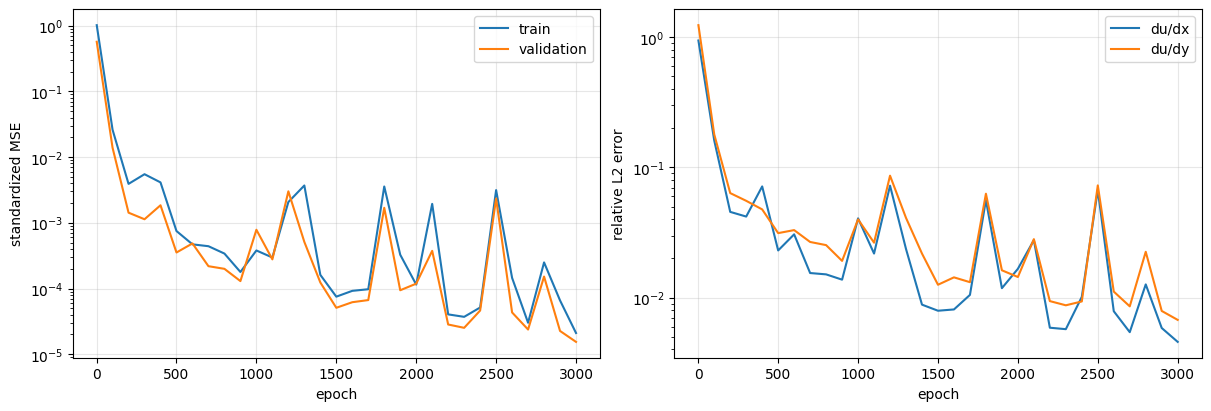

In [10]:
epochs = np.array([h['epoch'] for h in history])
train_losses = np.array([h['train_loss'] for h in history])
val_losses = np.array([h['val_loss'] for h in history])
rel_ux = np.array([h['rel_l2_du_dx'] for h in history])
rel_uy = np.array([h['rel_l2_du_dy'] for h in history])

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].semilogy(epochs, train_losses, label='train')
axes[0].semilogy(epochs, val_losses, label='validation')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('standardized MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(epochs, rel_ux, label='du/dx')
axes[1].semilogy(epochs, rel_uy, label='du/dy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('relative L2 error')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.show()

## Field plots

In [11]:
def make_grid(n=180):
    xs = torch.linspace(0.0, 1.0, n, device=device)
    ys = torch.linspace(0.0, 1.0, n, device=device)
    Xg, Yg = torch.meshgrid(xs, ys, indexing='xy')
    xy = torch.stack([Xg.reshape(-1), Yg.reshape(-1)], dim=1)
    return xy, Xg, Yg


model.eval()
grid_xy, Xg, Yg = make_grid(220)
with torch.no_grad():
    grid_true = exact_grad_u(grid_xy)
    grid_pred = unscale_grad(model(transform_xy(grid_xy)))
    grid_error = grid_pred - grid_true

n = Xg.shape[0]
true_np = grid_true.detach().cpu().numpy().reshape(n, n, 2)
pred_np = grid_pred.detach().cpu().numpy().reshape(n, n, 2)
err_np = grid_error.detach().cpu().numpy().reshape(n, n, 2)

print('grid max abs error du/dx:', np.max(np.abs(err_np[:, :, 0])))
print('grid max abs error du/dy:', np.max(np.abs(err_np[:, :, 1])))

grid max abs error du/dx: 0.561656525069381
grid max abs error du/dy: 0.6435279591471641


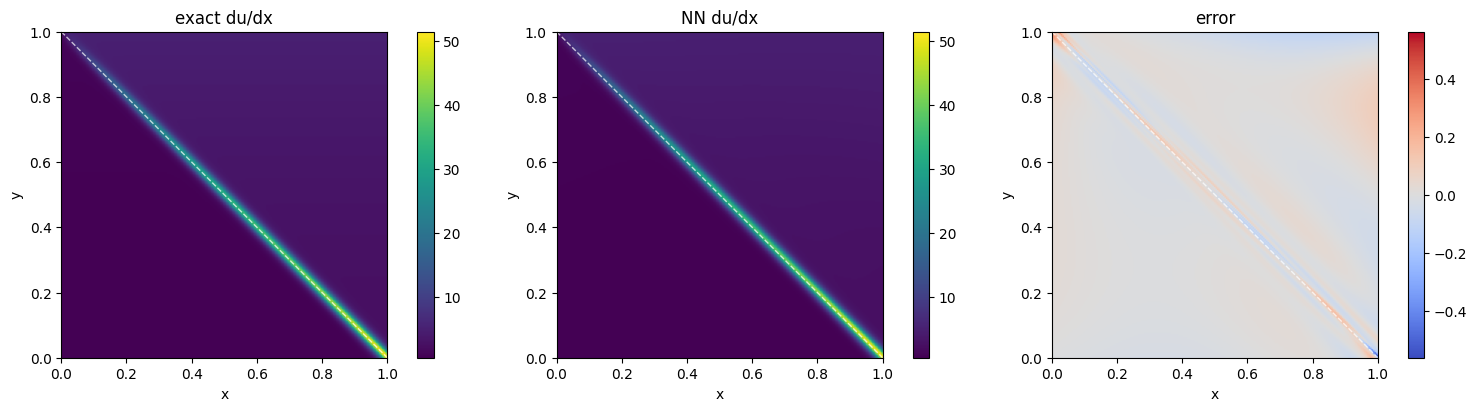

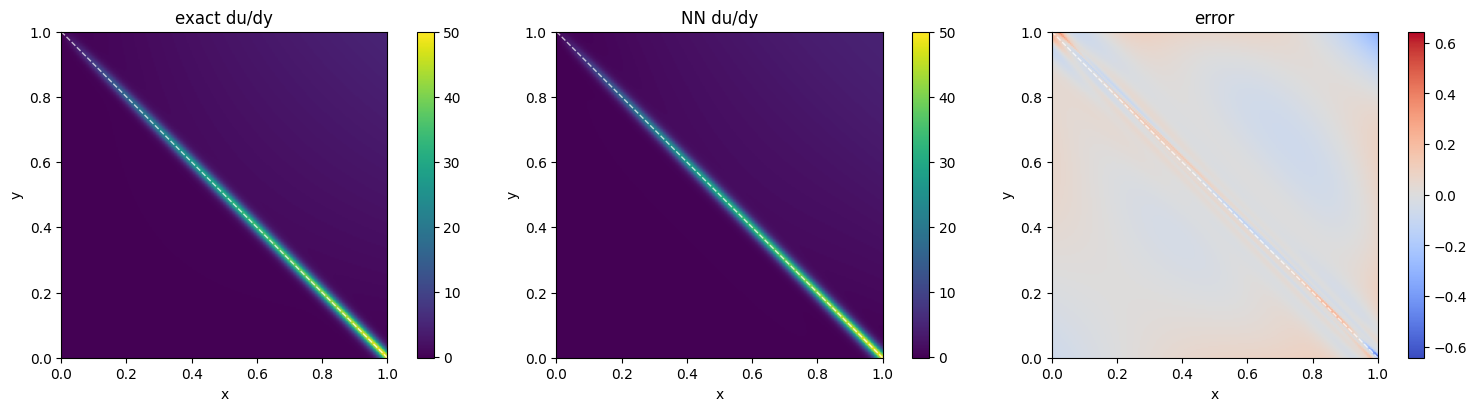

In [12]:
for comp, label in [(0, 'du/dx'), (1, 'du/dy')]:
    true = true_np[:, :, comp]
    pred = pred_np[:, :, comp]
    err = err_np[:, :, comp]

    vmin = min(true.min(), pred.min())
    vmax = max(true.max(), pred.max())
    emax = np.max(np.abs(err))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

    im0 = axes[0].imshow(true, origin='lower', extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[0].set_title(f'exact {label}')
    fig.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(pred, origin='lower', extent=[0, 1, 0, 1], vmin=vmin, vmax=vmax, cmap='viridis')
    axes[1].set_title(f'NN {label}')
    fig.colorbar(im1, ax=axes[1])

    im2 = axes[2].imshow(err, origin='lower', extent=[0, 1, 0, 1], vmin=-emax, vmax=emax, cmap='coolwarm')
    axes[2].set_title('error')
    fig.colorbar(im2, ax=axes[2])

    for ax in axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.plot([0, 1], [1, 0], 'w--', linewidth=1.0, alpha=0.7)

    plt.show()

## Optional: save the trained model

This saves the model weights and the normalization constants needed to use the trained gradient surrogate later.

In [13]:
out_dir = Path('outputs')
out_dir.mkdir(exist_ok=True)

checkpoint = {
    'state_dict': model.state_dict(),
    'eps': EPS,
    'use_layer_feature': USE_LAYER_FEATURE,
    'width': WIDTH,
    'depth': DEPTH,
    'x_mean': x_mean.detach().cpu(),
    'x_std': x_std.detach().cpu(),
    'g_mean': g_mean.detach().cpu(),
    'g_std': g_std.detach().cpu(),
}

torch.save(checkpoint, out_dir / 'gradient_fit_checkpoint.pt')
print('saved:', out_dir / 'gradient_fit_checkpoint.pt')

saved: outputs/gradient_fit_checkpoint.pt


## Interpretation

If the global relative error looks acceptable but the field error is concentrated along \(x+y=1\), the NN is under-resolving the stiff layer. Try increasing `N_LAYER`, `WIDTH`, `DEPTH`, or `EPOCHS`. If the plain input `(x,y)` struggles, set `USE_LAYER_FEATURE = True`; if that fixes the fit, the main difficulty is representing the layer coordinate.